In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [ ]:
data_folder = r'C:\Users\Default\Desktop\COMP370FinalProj\data\plot_data'

In [3]:
#loop through each folder in data_folder and read the csv files into a single dataframe
all_data = []

for folder in os.listdir(data_folder):
    folder_path = os.path.join(data_folder, folder)
    
    if not os.path.isdir(folder_path):
        continue  # skip non-folders
    
    month = folder.lower()  # store month name
    
    for file in os.listdir(folder_path):
        if file.endswith('.json'):
            file_path = os.path.join(folder_path, file)
            
            movie_data = pd.read_json(file_path)
            movie_name = file.replace('.json', '')
            movie_name = movie_name.replace('_', ' ')
            num_posts = len(movie_data)
            
            all_data.append({
                'movie': movie_name,
                'num_posts': num_posts,
                'month': month
            })

# Convert to a DataFrame
df = pd.DataFrame(all_data)



In [4]:
month_to_date = {
    'may': '2025-05-01',
    'june': '2025-06-01',
    'july': '2025-07-01',
    'august': '2025-08-01',
}

df['date'] = pd.to_datetime(df['month'].map(month_to_date))

In [5]:
df

,movie,num_posts,month,date
0,28 Years Later,19,august,2025-08-01
1,Ballerina,4,august,2025-08-01
2,Bride Hard,1,august,2025-08-01
3,Elio,6,august,2025-08-01
4,F1 The Movie,29,august,2025-08-01
5,How to Train Your Dragon,14,august,2025-08-01
6,Jurassic World Rebirth,5,august,2025-08-01
7,Kpop Demon Hunters,35,august,2025-08-01
8,M3GAN 2.0,12,august,2025-08-01
9,Materialists,9,august,2025-08-01


In [6]:
# Pivot so each movie is a column
pivot_df = df.pivot(index='date', columns='movie', values='num_posts').fillna(0)

movies = [
    "Kpop Demon Hunters", "Materialists", "Ballerina", "Bride Hard",
    "F1 The Movie", "Jurassic World Rebirth", "How to Train Your Dragon",
    "28 Years Later", "Elio", "M3GAN 2.0", "The Old Guard 2"
]

movie_colors = {
    "Kpop Demon Hunters": "#969696",
    "Materialists": "#c7c7c7",
    "Ballerina": "#ffa600",
    "Bride Hard": "#ff7c43",
    "F1 The Movie": "#f95d6a",
    "Jurassic World Rebirth": "#d45087",
    "How to Train Your Dragon": "#a05195",
    "28 Years Later": "#665191",
    "Elio": "#404BA7",
    "M3GAN 2.0": "#323B86",
    "The Old Guard 2": "#262D68"
}



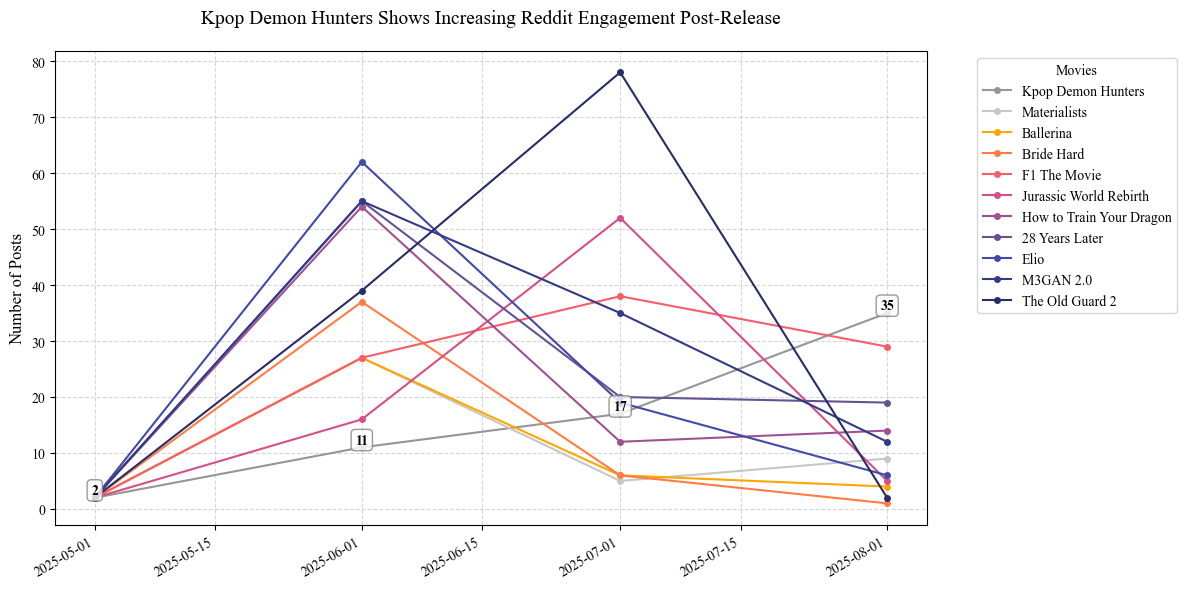

In [20]:
plt.figure(figsize=(12,6))  # wider for reports
plt.rcParams['font.family'] = 'Times New Roman'

movie_names = []

for movie in movies:
    if movie in pivot_df.columns:
        plt.plot(
            pivot_df.index,
            pivot_df[movie],
            marker='o',
            markersize=4,
            linewidth=1.5,
            label=movie,
            color=movie_colors[movie]
        )
        movie_names.append(movie)
        
        # Annotate Kpop Demon Hunters with professional look
        if movie == "Kpop Demon Hunters":
            for x, y in zip(pivot_df.index, pivot_df[movie]):
                plt.text(
                    x, y + 0.15, str(int(y)),
                    ha='center',
                    va='bottom',
                    fontsize=10,
                    color='black',
                    fontweight='bold',
                    bbox=dict(
                        facecolor='white',
                        edgecolor='gray',
                        alpha=0.8,
                        boxstyle='round,pad=0.3'
                    )
                )

# Titles and labels
plt.title("Kpop Demon Hunters Shows Increasing Reddit Engagement Post-Release", fontsize=14, pad=20)
plt.ylabel('Number of Posts', fontsize=12)

# Legend
plt.legend(labels=movie_names, title='Movies', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.gcf().autofmt_xdate()  # rotate dates
plt.tight_layout()

plt.show()